In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sympy as sp

# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [3]:
def gradient_descent(f_prime, x0, ep, iterations):
    x = x0
    for i in range(iterations):
        derivative = f_prime(x)
        if derivative > 0:
            x = x - ep
        elif derivative < 0:
            x = x + ep
        else:
            break
    return x

In [27]:
#Example 
def f_prime(x):
    return 2 * x
result = gradient_descent(f_prime=f_prime,x0=5,ep=0.1,iterations=10000)

print(result)

1.0269562977782698e-15


### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [24]:
%timeit gradient_descent(f_prime, x0=5, ep=0.1, iterations=10000)

1.56 ms ± 44.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [19]:
%timeit minimize(objective, x0=5)

760 μs ± 26.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
%timeit gradient_descent(f_prime, x0=10, ep=0.1, iterations=10000)

1.49 ms ± 38.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [25]:
%timeit minimize(objective, x0=10)

960 μs ± 66.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [29]:
%timeit gradient_descent(f_prime, x0=-10, ep=0.1, iterations=10000)

1.53 ms ± 51.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [30]:
%timeit minimize(objective, x0=-10)

969 μs ± 34.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [17]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 2, 2, 3, 4])

def loss(params):
    a, b = params
    prediction = a * x + b
    return np.sum((y - prediction) ** 2)

def fit_with_minimize():
    result = minimize(loss, x0=[1, 1])
    return result.x

def fit_with_polyfit():
    return np.polyfit(x, y, 1)

print("Minimize:", fit_with_minimize())
print("Polyfit:", fit_with_polyfit())

%timeit fit_with_minimize()
%timeit fit_with_polyfit()

Minimize: [0.49999997 1.10000008]
Polyfit: [0.5 1.1]
993 μs ± 107 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
30.6 μs ± 1.84 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In both instances, using the library resulted in a faster pro

### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

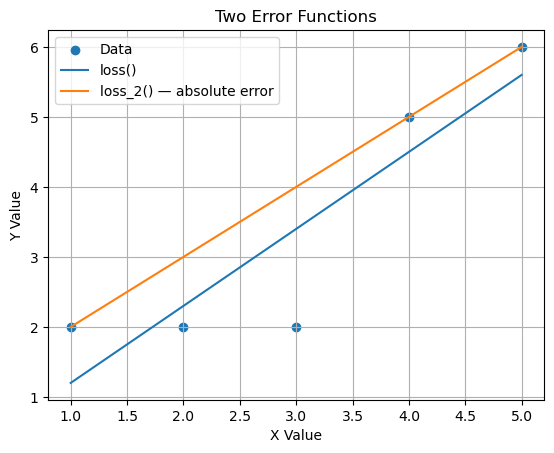

In [3]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 2, 2, 5, 6])

def loss(params):
    a, b = params
    prediction = a * x + b
    return np.sum((y - prediction) ** 2)

def loss_2(params):
    a, b = params
    prediction = a * x + b
    return np.sum(np.abs(y - prediction))

result_1 = minimize(loss, x0=[1, 1])
result_2 = minimize(loss_2, x0=[1, 1])

a1, b1 = result_1.x
a2, b2 = result_2.x

x_line = np.linspace(x.min(), x.max(), 100)

y_line_1 = a1 * x_line + b1
y_line_2 = a2 * x_line + b2

plt.scatter(x, y, label="Data")
plt.plot(x_line, y_line_1, label="loss()")
plt.plot(x_line, y_line_2, label="loss_2() — absolute error")

plt.xlabel("X Value")
plt.ylabel("Y Value")
plt.title("Two Error Functions")
plt.legend()
plt.grid()
plt.show()